# **Tutorial:** Real-time Object Detection with YOLO

In this tutorial, you will learn how to use the YOLOv26 model with OpenCV to automatically detect and draw bounding boxes around objects in an image.

### **Step 1: Install Required Packages**

Install the necessary packages including OpenCV and other dependencies:

In [2]:
%pip install --upgrade ultralytics
%pip install opencv-python
%pip install matplotlib
%pip install numpy==1.26.4 --force-reinstall

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


^C
Note: you may need to restart the kernel to use updated packages.


  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      + c:\Users\Lander\AppData\Local\Programs\Python\Python313\python.exe C:\Users\Lander\AppData\Local\Temp\pip-install-h66ycux_\numpy_771300cb1bc44e9b9aee6102ca62feac\vendored-meson\meson\meson.py setup C:\Users\Lander\AppData\Local\Temp\pip-install-h66ycux_\numpy_771300cb1bc44e9b9aee6102ca62feac C:\Users\Lander\AppData\Local\Temp\pip-install-h66ycux_\numpy_771300cb1bc44e9b9aee6102ca62feac\.mesonpy-zfiwawm5 -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\Lander\AppData\Local\Temp\pip-install-h66ycux_\numpy_771300cb1bc44e9b9aee6102ca62feac\.mesonpy-zfiwawm5\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.99
      Source dir: C:\Users\Lander\AppData\Local\Temp\pip-install-h66ycux_\numpy_771300cb1bc44e9b9aee6102ca62feac
      Build dir: C:\Users\Lander\AppData\Local\Temp\pip-inst

Verify the installations:

In [1]:
%pip show opencv-python ultralytics

Name: opencv-python
Version: 4.12.0.88
Summary: Wrapper package for OpenCV python bindings.
Home-page: https://github.com/opencv/opencv-python
Author: 
Author-email: 
License: Apache 2.0
Location: c:\Users\Lander\AppData\Local\Programs\Python\Python313\Lib\site-packages
Requires: numpy
Required-by: ultralytics
---
Name: ultralytics
Version: 8.4.21
Summary: Ultralytics YOLO 🚀 for SOTA object detection, multi-object tracking, instance segmentation, pose estimation and image classification.
Home-page: https://ultralytics.com
Author: 
Author-email: Glenn Jocher <glenn.jocher@ultralytics.com>, Jing Qiu <jing.qiu@ultralytics.com>
License: AGPL-3.0
Location: c:\Users\Lander\AppData\Local\Programs\Python\Python313\Lib\site-packages
Requires: matplotlib, numpy, opencv-python, pillow, polars, psutil, pyyaml, requests, scipy, torch, torchvision, ultralytics-thop
Required-by: 
Note: you may need to restart the kernel to use updated packages.


### **Step 2: Import Required Libraries**

Import the libraries you will use:

In [2]:
import numpy as np
import math
import cv2
from ultralytics import YOLO
from matplotlib import pyplot as plt

### **Step 3: Load the YOLOv26 Model**

Load the pre-trained YOLOv26 model (automatically downloads if not available):

In [3]:
# Load a pretrained YOLO model version 26, nano (n) size
model = YOLO('yolo26n.pt')  # Using nano version for speed, other options: yolov26s.pt (small), yolov26m.pt (medium), yolov26l.pt (large), yolov26x.pt (extra large)

In [4]:
# Show class names the model can detect 
model.names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

### **Step 4.1: Run YOLO on your webcam video (the simple way)**

In [5]:
# Run YOLO model on your webcam
results = model.predict(
    source=0, # source=0 uses the default webcam, use source=1 for an external camera
    show=True, # show=True to display the video feed with detections in a window 
    stream=True, # stream=True for real-time processing of video frames
    imgsz=256, # resize frames to 256x256 for faster processing and lower resource usage
    vid_stride=3, # process every 3rd frame to reduce CPU/GPU load
    save=False # do not save the video output (this saves disk space and speeds up processing)
    #verbose=False # stops printing per-frame logs
    #conf=0.3, # confidence threshold of 30% (default is 0.25). Adjust as needed.
)

### **Step 4.2: Run YOLO on your webcam video (the complete way)**

In [ ]:
# Configure video capture from the camera
capture = cv2.VideoCapture(0)  # Open the default camera

# Define class names (YOLO COCO dataset classes)
classNames = ["person", "bicycle", "car", "motorbike", "aeroplane", "bus", "train", "truck", "boat",
              "traffic light", "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat",
              "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella",
              "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite", "baseball bat",
              "baseball glove", "skateboard", "surfboard", "tennis racket", "bottle", "wine glass", "cup",
              "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange", "broccoli",
              "carrot", "hot dog", "pizza", "donut", "cake", "chair", "sofa", "pottedplant", "bed",
              "diningtable", "toilet", "tvmonitor", "laptop", "mouse", "remote", "keyboard", "cell phone",
              "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock", "vase", "scissors",
              "teddy bear", "hair drier", "toothbrush"]

# Set the image width and height
capture.set(cv2.CAP_PROP_FRAME_WIDTH, 640)  # Image width
capture.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)  # Image height

# Start a loop to process camera frames
while True:
    success, img = capture.read()  # Capture a frame

    # Perform object detection on the captured image (using the pre-trained YOLO model we loaded earlier)
    results = model(img, stream=True)  # Stream generator to process detection results in real time

    # Process the detection results (we can have multiple objects detected in a single frame)
    for r in results:
        boxes = r.boxes

        # Iterate over the detected bounding boxes
        for box in boxes:
            # Get the bounding box coordinates in xyxy format
            x1, y1, x2, y2 = box.xyxy[0]
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)  # Convert to integer values

            # Draw the bounding box on the image
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 255), 1)

            # Get the detection confidence (value between 0 and 1) and round to two decimal places
            confidence = math.ceil((box.conf[0]*100))/100
            print("Confidence --->", confidence)

            # Get the numeric identifier of the detected class name
            cls = int(box.cls[0])
            print("Class name -->", classNames[cls])

            # Display the class name next to the bounding box
            org = [x1, y1]  # Coordinates of the top-left corner for the text
            font = cv2.FONT_HERSHEY_SIMPLEX # Font type
            fontScale = 1  # Font scale
            color = (255, 0, 0)  # Color: Blue (BGR format)
            thickness = 1  # Text line thickness
            cv2.putText(img, classNames[cls], org, font, fontScale, color, thickness)

    # Display the image with a window name and the processed image with detections
    cv2.imshow('YOLO Detection', img)

    # Exit the loop if the 'q' key is pressed
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

# Release the camera and close all windowsq
capture.release()
cv2.destroyAllWindows()


0: 480x640 1 person, 224.5ms
Confidence ---> 0.3
Class name --> person
Speed: 11.1ms preprocess, 224.5ms inference, 3.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 85.0ms
Confidence ---> 0.95
Class name --> person
Speed: 2.9ms preprocess, 85.0ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 80.7ms
Confidence ---> 0.95
Class name --> person
Speed: 2.7ms preprocess, 80.7ms inference, 0.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 72.6ms
Confidence ---> 0.95
Class name --> person
Speed: 2.3ms preprocess, 72.6ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 74.7ms
Confidence ---> 0.94
Class name --> person
Speed: 2.4ms preprocess, 74.7ms inference, 0.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 69.3ms
Confidence ---> 0.93
Class name --> person
Speed: 2.2ms preprocess, 69.3ms inference, 0.2ms postprocess per image at shape (

KeyboardInterrupt: 

: 

### **Step 5.1: Run YOLO on an Image (the simple way)**

In [6]:
# Run yolo model on an image
results = model.predict(source="./cat.jpg", show=True)


image 1/1 c:\Users\Lander\Desktop\U\10mo\Vision\deteccion\cat.jpg: 640x640 1 cat, 100.5ms
Speed: 6.7ms preprocess, 100.5ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


### **Step 5.2: Run YOLO on an Image (the complete way)**

Load your image and prepare it for inference:

In [7]:
# Load an image (change the path to your image file)
image_bgr = cv2.imread('./cat.jpg')

Run inference

In [8]:
# Run inference
results = model(image_bgr)


0: 640x640 1 cat, 85.7ms
Speed: 4.4ms preprocess, 85.7ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)


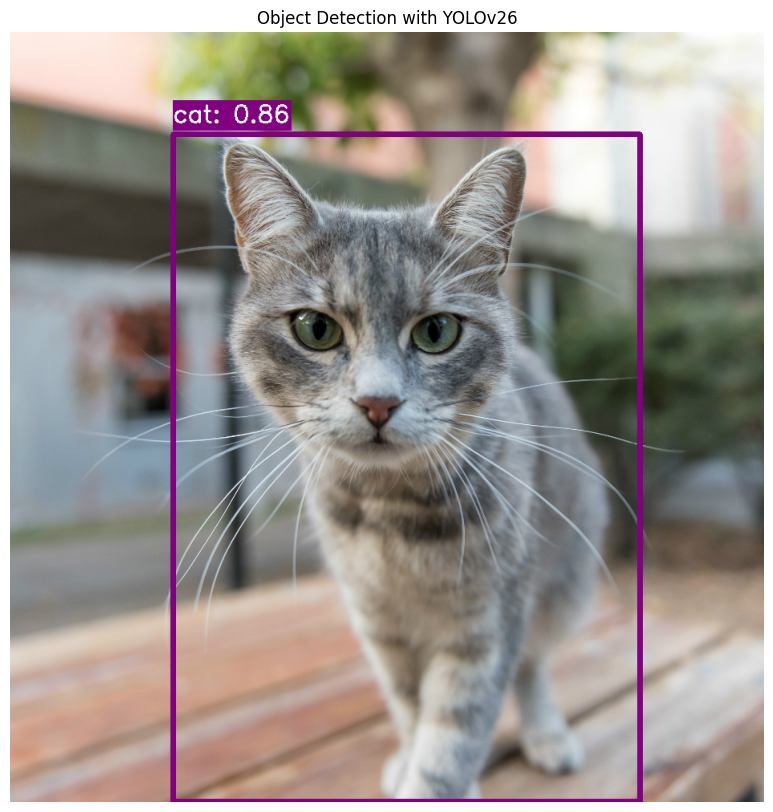

Detected 1 objects:
  1. cat (confidence: 0.86)


In [9]:
# Extract detection results
boxes = results[0].boxes  # Bounding boxes
scores = boxes.conf       # Confidence scores
class_ids = boxes.cls     # Class IDs

# Create a copy of the original image to draw on
image_with_boxes = image_bgr.copy()

# Define colors for different classes
colors = [(0, 255, 0), (0, 0, 255), (255, 0, 0), (255, 255, 0), 
          (0, 255, 255), (255, 0, 255), (255, 165, 0), (128, 0, 128)]

# Draw bounding boxes and labels for each detection
for i, (box, score, class_id) in enumerate(zip(boxes.xyxy, scores, class_ids)):
    # Convert tensor to numpy array
    x1, y1, x2, y2 = box.cpu().numpy()
    class_id = int(class_id.cpu().numpy())
    score = float(score.cpu().numpy())
    
    # Get class name and color
    class_name = model.names[class_id]
    color = colors[class_id % len(colors)]
    
    # Draw bounding box
    cv2.rectangle(image_with_boxes, (int(x1), int(y1)), (int(x2), int(y2)), color, 5)
    
    # Create label text
    label = f"{class_name}: {score:.2f}"
    
    # Calculate text position
    label_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 1, 2)[0]
    label_y = max(int(y1) - 10, label_size[1] + 10)
    
    # Draw text background
    cv2.rectangle(image_with_boxes, 
                 (int(x1), label_y - label_size[1] - 10),
                 (int(x1) + label_size[0], label_y + 5),
                 color, -1)
    
    # Draw text
    cv2.putText(image_with_boxes, label, 
               (int(x1), label_y - 5), 
               cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    
# Convert from BGR to RGB for matplotlib
image_with_boxes_rgb = cv2.cvtColor(image_with_boxes, cv2.COLOR_BGR2RGB)

# Display the result
plt.figure(figsize=(12, 10))
plt.imshow(image_with_boxes_rgb)
plt.title('Object Detection with YOLOv26')
plt.axis('off')
plt.show()

# Print detection summary
print(f"Detected {len(boxes)} objects:")
for i, (class_id, score) in enumerate(zip(class_ids, scores)):
    class_id = int(class_id.cpu().numpy())
    score = float(score.cpu().numpy())
    print(f"  {i+1}. {model.names[class_id]} (confidence: {score:.2f})")

### **Step 6.1: Run Object Detection on a saved video (the simple way)**

Inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos.

In [10]:
# YOLO on a saved video
results = model.predict(source='./car-detection.mp4', show=True, stream=True)

### **Step 6.2: Run Object Detection on a saved video (the complete way)**

In [12]:
# Load YOLO model
model = YOLO('./yolo26n.pt')

# Configure your video path
#video_path = "./fruit-and-vegetable-detection.mp4"
#video_path = "./car-detection.mp4"
video_path = "./worker-zone-detection.mp4"

# Open video
cap = cv2.VideoCapture(video_path)

# Verify video opened correctly
if not cap.isOpened():
    print("Error: Could not open video. Check the path.")
else:
    print("Video loaded successfully. Press 'q' to exit.")
    
    # Process each video frame
    while True:
        ret, frame = cap.read()
        
        if not ret:
            break  # Finish when video ends
            
        # Run detection with YOLO
        results = model(frame)
        
        # Draw bounding boxes
        for result in results:
            boxes = result.boxes
            for box in boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                confidence = float(box.conf[0].cpu().numpy())
                class_id = int(box.cls[0].cpu().numpy())
                
                # Only show detections with confidence > 50%
                if confidence > 0.5:
                    # Draw rectangle
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    
                    # Show label
                    label = f"{model.names[class_id]}: {confidence:.2f}"
                    cv2.putText(frame, label, (x1, y1-10), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        
        # Show frame with detections
        cv2.imshow('Object Detection', frame)
        
        # Exit with 'q' key
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

# Release resources
cap.release()
cv2.destroyAllWindows()
print("Processing completed.")

Video loaded successfully. Press 'q' to exit.

0: 384x640 1 person, 78.5ms
Speed: 2.6ms preprocess, 78.5ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 57.0ms
Speed: 2.6ms preprocess, 57.0ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 60.7ms
Speed: 2.8ms preprocess, 60.7ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 54.3ms
Speed: 2.4ms preprocess, 54.3ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 61.3ms
Speed: 3.1ms preprocess, 61.3ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 56.3ms
Speed: 2.5ms preprocess, 56.3ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 58.8ms
Speed: 2.7ms preprocess, 58.8ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 65.9ms
Speed: 2.5ms preprocess, 65.9ms inference, 

## **Activity**

### **Option 1: Mathematics Track**

Clone your repository from GitHub and run the system directly on the Jetson Nano.

#### Access to the Jetson Nano

You will be provided with:
- Username
- Jetson Nano IP address
- Password

Use your computer's terminal to connect:

`ssh username@jetson_ip`

#### 1. Clone the repository
`git clone https://github.com/user/repository.git`

#### 2. Access the project directory
`cd repository`

#### 3. Create virtual environment and install dependencies
`python3 -m venv env`
`source env/bin/activate`
`pip install -r requirements.txt`

#### 4. Run the virtual environment
`python YOLO-Real-Time.py`

### **Grading Rubric**

| **Criteria** | **Points** | **Description** |
|-------------|-----------|----------------|
| **1. SSH Connection** | 2 | Successfully establishes SSH connection to Jetson Nano. Properly handles authentication and connection setup. |
| **2. Environment Setup** | 3 | Creates virtual environment and installs all dependencies correctly. Resolves any platform-specific issues. |
| **3. Application Execution** | 3 | Runs YOLO real-time detection successfully on Jetson Nano. Handles hardware acceleration properly. |
| **4. Performance Optimization** | 2 | Implements optimizations for Jetson Nano hardware. Maintains acceptable frame rate for real-time detection. |

Total: 10 points

In [ ]:
# Write your code here...


### **Option 2: Computer Science Track**

Create a Dockerfile in your Jetson Nano folder:

#### Dockerfile

`FROM nvcr.io/nvidia/l4t-pytorch:r32.7.1-pth1.11-py3`
`RUN apt-get update && apt-get install -y python3-pip libopencv-dev`
`RUN pip3 install ultralytics opencv-python`

`COPY . /app`
`WORKDIR /app`

`CMD ["python3", "YOLO-Real-Time.py"]`

#### 1. Clone your repository
`git clone https://github.com/user/repository.git`
`cd repository`

#### 2. Build the Docker image
`sudo docker build -t yolov8-detector .`

#### 3. Run the container
`sudo docker run --rm -it --net=host --device=/dev/video0 yolov8-detector`

### Steps to build and run:

#### 1. Clone your repository
`git clone https://github.com/user/repository.git`
`cd repository`

#### 2. Build the Docker image
`sudo docker build -t yolov8-detector .`

#### 3. Run the container
`sudo docker run --rm -it --net=host --device=/dev/video0 yolov8-detector`

### **Grading Rubric**

| **Criteria** | **Points** | **Description** |
|-------------|-----------|----------------|
| **1. Repository Setup** | 2 | Successfully clones repository and sets up environment. All dependencies installed correctly without errors. |
| **2. Docker Implementation** | 3 | Dockerfile is properly configured with all necessary dependencies. Image builds successfully without errors. |
| **3. Container Execution** | 3 | Container runs successfully with camera access. Real-time detection works properly in Docker environment. |
| **4. System Performance** | 2 | Application runs smoothly with acceptable frame rate. Handles video streaming without crashes or major issues. |

Total: 10 points

In [ ]:
# Write your code here...




### **Option 3: Master's in Artificial Intelligence / Data Science**

In this option, the work will be developed **locally on your personal computers**.

#### Objective
Design a **specific object detection application** using YOLO (You Only Look Once), focused on **a limited subset of classes**. The system must show that **it only detects the activated classes**, visually ignoring objects belonging to deactivated classes (even if they are present in the image).

#### Instructions

1. **Define a concrete application and the problem it solves**, for example: vehicle detection, fruits detection, etc.
2. **Select between 2 and 4 classes** from the YOLOv26 model to detect.
3. **Modify the model logic** or post-processing so that **only the selected classes are shown**.
4. Run the application on video where **objects from non-activated classes** are also present to demonstrate that the system **ignores those classes**.
5. Show the results clearly, visually indicating the detected and non-detected objects.

#### Technical Requirements

- Use `ultralytics` with `YOLO` in any version.
- You have to use your webcam (no static images nor local video allowed).

#### Deliverable

Must be uploaded to the virtual classroom:

- **Jupyter Notebook in PDF format** containing: 
- Commented code
- Application title and the problem it solves
- List of activated classes
- Screenshots or test images with results showing:
  - Objects *correctly detected* according to the activated classes.
  - Objects *not detected* because they belong to deactivated classes (even if present in the image).

### **Grading Rubric**

| **Criteria** | **Points** | **Description** |
|-------------|-----------|----------------|
| **1. Application Definition and Problem Statement** | 1 | Clearly defines a specific object detection application and its practical use case. Selects appropriate classes for the application context. |
| **2. Class Selection and Justification** | 1 | Selects between 2-4 relevant classes from YOLOv8 model. Demonstrates thoughtful choice of classes for the specific application. |
| **3. Implementation** | 4 | Successfully modifies the model logic or post-processing to only show selected classes. Code is functional and properly ignores non-selected classes. |
| **4. Testing & Evidence** | 3 | Provides a clear test showing both detected (activated classes) and ignored (deactivated classes) objects. Evidence demonstrates the filtering works correctly. |
| **5. Documentation** | 1 | Delivers complete documentation including PDF notebook, application title, class list, and proper screenshots. Submission is well-organized and professional. |

Total: 10 points

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>

# Sistema de Monitoreo de Ciclovía con YOLOv8

## 1. Problema

Las ciclovías están diseñadas para el uso exclusivo de bicicletas.  
Sin embargo, en muchas ciudades las motocicletas invaden estas vías, lo que genera riesgos para la seguridad de los ciclistas.

El objetivo de este proyecto es crear un **sistema de visión por computadora capaz de detectar bicicletas y motocicletas en video**, para identificar cuándo un vehículo no permitido circula por la ciclovía.

---

## 2. Selección de Clases

Se utilizaron dos clases del modelo YOLOv8 entrenado con el dataset COCO:

- **Bicycle (ID 1)** → vehículo permitido en la ciclovía  
- **Motorcycle (ID 3)** → vehículo no permitido  

Estas clases fueron seleccionadas porque representan directamente el problema que se desea monitorear.

---

## 3. Implementación

Se utilizó el modelo **YOLOv8 Nano (yolov8n.pt)** para realizar detección de objetos en cada frame del video.

El modelo fue configurado para detectar **solo las clases seleccionadas** utilizando el parámetro `classes`.

Visualización del sistema:

- **Caja verde → Bicicleta (permitido)**  
- **Caja roja → Motocicleta (NO permitido)**  

Esto permite identificar rápidamente infracciones en la ciclovía.

---

## 4. Pruebas

El sistema fue probado con un video de una ciclovía.

Resultados observados:

- Las bicicletas se detectan correctamente.
- Las motocicletas se identifican como **vehículos no permitidos**.
- Otros objetos como personas o autos son ignorados.

Esto demuestra que el sistema **filtra correctamente las clases relevantes**.



In [1]:
from ultralytics import YOLO
import cv2

# cargar modelo
model = YOLO("yolov8n.pt")

# IDs de clases que queremos detectar
classes_to_detect = [1, 3]   # bicycle, motorcycle

cap = cv2.VideoCapture("ciclovia.mp4")

while cap.isOpened():

    ret, frame = cap.read()
    if not ret:
        break

    # SOLO detectar estas clases
    results = model(frame, classes=classes_to_detect)

    for r in results:
        for box in r.boxes:

            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            label = model.names[cls_id]

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            if label == "bicycle":
                color = (0,255,0)
                text = f"Bicycle {conf:.2f}"

            else:  # motorcycle
                color = (0,0,255)
                text = f"Motorcycle - NOT ALLOWED"

            cv2.rectangle(frame,(x1,y1),(x2,y2),color,2)
            cv2.putText(frame,text,(x1,y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX,0.6,color,2)

    cv2.imshow("Bike Lane Monitor", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()


0: 384x640 5 bicycles, 372.1ms
Speed: 8.3ms preprocess, 372.1ms inference, 8.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 bicycles, 262.4ms
Speed: 6.1ms preprocess, 262.4ms inference, 12.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 bicycles, 196.4ms
Speed: 8.4ms preprocess, 196.4ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 bicycles, 192.5ms
Speed: 4.8ms preprocess, 192.5ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 bicycles, 301.5ms
Speed: 1.9ms preprocess, 301.5ms inference, 8.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 bicycles, 490.4ms
Speed: 23.0ms preprocess, 490.4ms inference, 4.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 bicycles, 135.8ms
Speed: 2.6ms preprocess, 135.8ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 bicycles, 139.9ms
Speed: 2.6ms preprocess, 139.9ms inference, 3.0ms postpr